In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("C:/Users/HITESH/Downloads/reviews_dataset.csv")

In [2]:
df.head()

,review
0,This product is amazing and works perfectly
1,"Very bad experience, waste of money"
2,"Average quality, not too good not too bad"
3,Excellent service and great support
4,"Terrible product, broke in two days"


In [3]:
import re

def clean(text):
    text = re.sub(r'[^a-zA-Z]', ' ', str(text))
    return text.lower()

df['cleaned'] = df['review'].apply(clean)

In [4]:
from textblob import TextBlob

df['score'] = df['cleaned'].apply(lambda x: TextBlob(x).sentiment.polarity)

In [5]:
def label(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df['sentiment'] = df['score'].apply(label)

In [7]:
df['sentiment'].value_counts()

sentiment
Positive    5
Negative    5
Name: count, dtype: int64

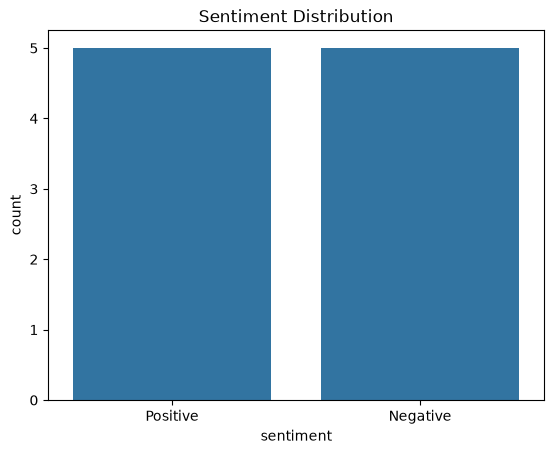

In [8]:
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()